In [4]:
import pandas as pd
import sqlite3

# 1. EXTRACT
df = pd.read_csv('banking.csv')

print("Original data:")
print(df.head())

Original data:
   age          job  marital          education  default housing loan  \
0   44  blue-collar  married           basic.4y  unknown     yes   no   
1   53   technician  married            unknown       no      no   no   
2   28   management   single  university.degree       no     yes   no   
3   39     services  married        high.school       no      no   no   
4   55      retired  married           basic.4y       no     yes   no   

    contact month day_of_week  ...  campaign  pdays  previous     poutcome  \
0  cellular   aug         thu  ...         1    999         0  nonexistent   
1  cellular   nov         fri  ...         1    999         0  nonexistent   
2  cellular   jun         thu  ...         3      6         2      success   
3  cellular   apr         fri  ...         2    999         0  nonexistent   
4  cellular   aug         fri  ...         1      3         1      success   

  emp_var_rate  cons_price_idx  cons_conf_idx  euribor3m  nr_employed  y  
0 

In [5]:
df.shape

(41188, 21)

In [6]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp_var_rate      0
cons_price_idx    0
cons_conf_idx     0
euribor3m         0
nr_employed       0
y                 0
dtype: int64

In [7]:
df = df.drop_duplicates()

In [8]:
df['y'] = df['y'].map({0: 'no', 1: 'yes'})

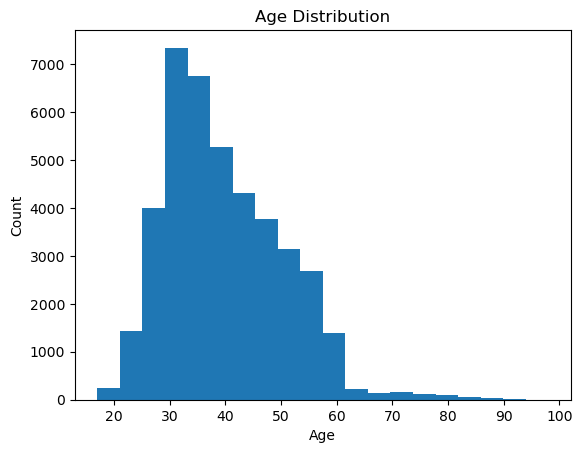

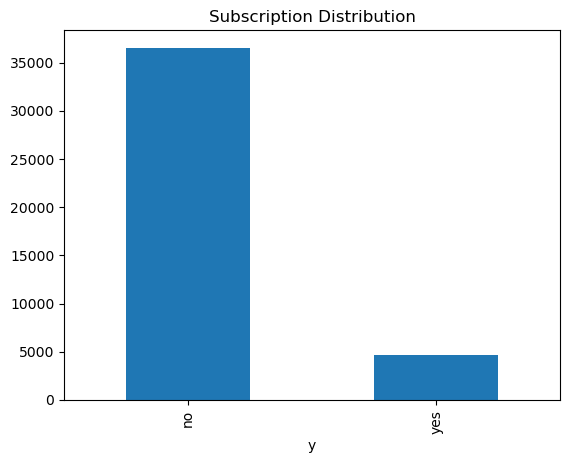

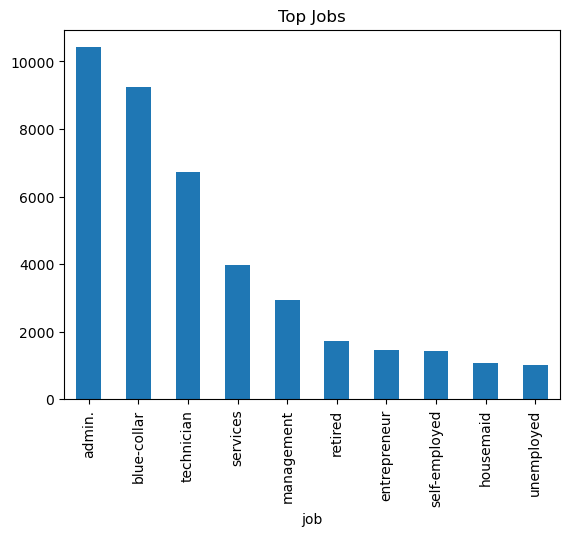

In [10]:
import matplotlib.pyplot as plt

# 1. Распределение возраста
plt.hist(df['age'], bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# 2. Подписки (target)
df['y'].value_counts().plot(kind='bar')
plt.title('Subscription Distribution')
plt.show()

# 3. Jobs
df['job'].value_counts().head(10).plot(kind='bar')
plt.title('Top Jobs')
plt.show()

In [9]:
conn = sqlite3.connect('banking.db')

df.to_sql('banking', conn, if_exists='replace', index=False)

print("\nData loaded into database")

conn.close()


Data loaded into database
